# Comparación jerárquica de modelos entrenados

In [ ]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from loguru import logger

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

from config.levels import LEVELS_BY_ID
from src.data.dataset import reconstruct_test_data
from src.evaluation import build_predictions_report
from src.evaluation.point import bias, rmse, wape
from src.evaluation.scaled import compute_naive_scales

artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))

In [ ]:
comparative = []
all_model_results = []

for artifact_path in artifact_paths:

    artifact = joblib.load(artifact_path)

    grainly = "daily" if "daily" in artifact_path.name else "weekly"

    comparative.append({
        "level": artifact["level"],
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grainly,
        "winner_family": artifact["winner_family"],
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    })

    # Guarda el detalle de TODOS los modelos evaluados en este nivel
    for model_result in artifact["model_results"]:
        all_model_results.append({
            "level": artifact["level"],
            "level_label": artifact["level_label"],
            "level_id": artifact["level_id"],
            "grainly": grainly,
            **model_result,
        })

df_comparative = pd.DataFrame(comparative)
df_all_models = pd.DataFrame(all_model_results)

In [ ]:
df_model_avg = (
    df_all_models
    .groupby(["model","grainly"])[["wape", "wrmsse"]]
    .mean()
    .sort_values("wrmsse")
)

df_model_avg['n_levels'] = df_all_models.groupby(["model","grainly"])["level_id"].nunique()

In [ ]:
df_model_avg.query('n_levels == 9 and grainly == "daily"')

In [ ]:
is_tuned_variant = df_all_models["model"].str.contains(
    r"\(bench, selected features\)|\(final, Optuna\)|\(final, tuned\)|\(final, bench default\)",
    regex=True
)

df_fair = df_all_models[~is_tuned_variant].copy()
df_tuned_variants = df_all_models[is_tuned_variant].copy()

In [ ]:
df_tuned_avg = (
    df_tuned_variants
    .groupby(["model","grainly"])[["wape", "wrmsse"]]
    .mean()
)

df_tuned_avg["n_levels"] = df_tuned_variants.groupby(["model","grainly"]).size()
df_tuned_avg = df_tuned_avg.sort_values("wape").reset_index()

df_tuned_avg = df_tuned_avg.query("grainly == 'daily'")

df_tuned_avg.nsmallest(10, "wape")

In [ ]:
df_fair_avg = (
    df_fair
    .groupby(["model","grainly"])[["wape", "wrmsse"]]
    .mean()
)

df_fair_avg["n_levels"] = df_fair.groupby(["model","grainly"]).size()
df_fair_avg = df_fair_avg.sort_values("wape").reset_index()

df_fair_avg = df_fair_avg.query("grainly == 'daily'")

df_fair_avg.nsmallest(10, "wape")

In [ ]:
ml_families = ["xgboost", "lightgbm", "histgb", "catboost", "ridge"]
bench_names = [f"{fam} (bench)" for fam in ml_families]

df_bench_ml = df_fair[df_fair["model"].isin(bench_names)].copy()
df_bench_ml["family"] = df_bench_ml["model"].str.replace(r" \(bench\)$", "", regex=True)

df_bench_ml = df_bench_ml[['level','grainly','family','wape','wrmsse']].sort_values(['level','grainly','family']).head(10)

In [ ]:
ml_models = df_bench_ml.groupby(["grainly",'family']).mean(numeric_only=True).reset_index()


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=ml_models,
    x="grainly",
    y="wape",
    hue="family",
    palette="muted",
    ax=ax
)

ax.set_title("Comparativo WAPE promedio entre modelos ML del total de 9 niveles", fontsize=13, weight="bold", loc="left", pad=20)
ax.set_xlabel("")
ax.set_ylabel("WAPE", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Modelo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=ml_models,
    x="grainly",
    y="wrmsse",
    hue="family",
    palette="muted",
    ax=ax
)

ax.set_title("Comparativo WRMSSE promedio entre modelos ML del total de 9 iteraciones", fontsize=13, weight="bold", loc="left", pad=20)
ax.set_xlabel("")
ax.set_ylabel("WRMSSE", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Modelo", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 0. Comparativo

In [ ]:
artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))

comparative = []

for artifact_path in artifact_paths:

    artifact = joblib.load(artifact_path)

    grainly = "daily" if "daily" in artifact_path.name else "weekly"

    comparative.append({
        "level": artifact["level"],
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grainly,
        "winner_family": artifact["winner_family"],
        "wape_test": artifact["wape_test"],
        "wrmsse_test": artifact["wrmsse_test"],
        "wape_valid": artifact["wape_valid"],
        "wrmsse_valid": artifact["wrmsse_valid"],
    })

df_comparative = pd.DataFrame(comparative)

df_comparative

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

fig, ax = plt.subplots(figsize=(8, 5))

order = df_comparative['winner_family'].value_counts().index
sns.countplot(
    data=df_comparative,
    x='winner_family',
    hue='grainly',
    order=order,
    palette='muted',
    ax=ax
)

ax.set_title('Modelo ganador de ML para por tipo de frecuencia', fontsize=13, weight='bold', pad=20, loc='left')
ax.set_xlabel('')
ax.set_ylabel('Modelos elegidos', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='', frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=df_comparative,
    x="level",
    y="wape_test",
    hue="grainly"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")
plt.yticks(np.arange(0, 0.13, 0.025))

plt.xlabel('')

plt.title("Comparación del WAPE ent test según nivel de agregación y frecuencia", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=df_comparative,
    x="level",
    y="wrmsse_test",
    hue="grainly"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 1.25, 0.25))

plt.title("Comparación del WRMSSE de test según nivel de agregación y frecuencia", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df_metrics_long = df_comparative.melt(
    id_vars=["level_label", "grainly"],
    value_vars=["wape_test", "wape_valid", "wrmsse_test", "wrmsse_valid"],
    var_name="metric_conjunto",
    value_name="valor",
)

df_metrics_long[["metric", "conjunto"]] = df_metrics_long["metric_conjunto"].str.split("_", expand=True)

df_metrics_long.drop(columns=["metric_conjunto"], inplace=True)

df_metrics_long = df_metrics_long.set_index('level_label')

df_metrics_long.head()

In [ ]:
df_wrmsse_daily = df_metrics_long.query("metric == 'wrmsse' and grainly == 'daily'")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_wrmsse_daily,
    x="level_label",
    y="valor",
    hue="conjunto"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.yticks(np.arange(0, 1.75, 0.25))

plt.ylabel("WRMSSE")

plt.title("Comparación del WRMSSE de conjuntos test vs valid", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Frecuencia",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df_wape_daily = df_metrics_long.query("metric == 'wape' and grainly == 'daily'")

plt.figure(figsize=(9, 4))
sns.barplot(
    data=df_wape_daily,
    x="level_label",
    y="valor",
    hue="conjunto"
)

for container in plt.gca().containers:
    for bar in container:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            size=9
        )

plt.xticks(rotation=45, ha="right")

plt.ylabel("WAPE")

plt.yticks(np.arange(0, .6, 0.1))

plt.title("Comparación del WAPE de conjuntos test vs valid", fontsize=12, fontweight="bold", pad=15, loc="left")

plt.legend(
    title="Conjunto",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 1. Carga de artifacts, reconstrucción de test y predicciones

## 1.1 Carga

In [ ]:
DIMS = ["dept_id", "cat_id", "store_id", "state_id"]

def load_level(artifact_path: Path) -> dict:
    '''Carga un artifact, reconstruye su X_test/train/test y arma el detalle de
    predicciones (df_pred) con las columnas de dimension (dept_id/store_id/...)
    pegadas desde X_test, para poder reagregar a cualquier nivel mas agregado.'''
    artifact = joblib.load(artifact_path)
    model = artifact["model"]

    X_test, y_test, train, test = reconstruct_test_data(artifact)
    y_pred = model.predict(X_test)

    metrics, df_pred = build_predictions_report(
        train, test, y_test, y_pred, target_col=artifact["target"],
    )
    dims_available = [d for d in DIMS if d in X_test.columns]
    df_pred = df_pred.join(X_test[dims_available])

    return {
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "level": artifact["level"],
        "model_class": type(model).__name__,
        "n_series": df_pred["series_id"].nunique(),
        "metrics": metrics,
        "df_pred": df_pred,
        "train": train,
        "dims_available": dims_available,
    }


artifact_paths = sorted(Path("../artifacts/models").glob("*_artifact.pkl"))
logger.info("Artifacts encontrados: {}", [p.name for p in artifact_paths])

LEVELS = {}
for path in artifact_paths:
    result = load_level(path)
    LEVELS[result["level_label"]] = result
    logger.info(
        "{} | {} series | modelo={} | WAPE test={:.2%} | WRMSSE test={:.3f}",
        result["level"], result["n_series"], result["model_class"],
        result["metrics"]["wape"], result["metrics"]["wrmsse"],
    )


## 2. Resumen de cada modelo en su propio nivel nativo

In [ ]:
summary_rows = []
for level_id, res in sorted(LEVELS.items()):
    m = res["metrics"]
    summary_rows.append({
        "level_label": res["level_label"],
        "level": res["level"],
        "n_series": res["n_series"],
        "modelo": res["model_class"],
        "wape": m["wape"],
        "wrmsse": m["wrmsse"],
        "bias": m["bias"],
        "rmse": m["rmse"],
    })

df_summary = pd.DataFrame(summary_rows).set_index("level_label")
df_summary.style.format({"wape": "{:.2%}", "wrmsse": "{:.3f}", "bias": "{:.2%}", "rmse": "{:,.1f}"})


## 3. Comparación al nivel TOTAL

Se agregan (`groupby("date").sum()`) las predicciones de cada nivel a la serie
total y se comparan contra el mismo real (`sales`), que por construcción es
idéntico en todos los niveles. Esto se hace **por separado para daily y para
weekly**: cada nivel (1-8) tiene artifact nativo en ambas frecuencias, así que
no hace falta reagregar una a la otra para comparar contra L1 (que también
tiene ambos grains) -- se compara peras con peras, daily contra actual diario y
weekly contra actual semanal, sin mezclar granularidades. Es un primer paso
hacia una reconciliación jerárquica más formal (bottom-up ya está acá; top-down
por proporciones históricas o MinT/optimal reconciliation -- p.ej. con
`hierarchicalforecast` -- quedan como extensión natural).

In [ ]:
def aggregate_to_total(df_pred: pd.DataFrame) -> pd.DataFrame:
    agg = df_pred.groupby("date").agg(actual=("sales", "sum"), y_pred=("y_pred", "sum"))
    return agg


def grain_of(res: dict) -> str:
    return res["level_label"].rsplit("_", 1)[-1]


def level_col(level_id: int) -> str:
    '''Etiqueta legible para una columna de nivel, p.ej. "L3_cat" en vez de "L3".'''
    return f"L{level_id}_{LEVELS_BY_ID[level_id].name}"


# Solo se agregan al total los niveles que particionan por completo la serie total
# (item/item_store, 10-12, están filtrados a un subconjunto dept/store y no sumarían al total real).
VALID_LEVELS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Cada nivel 1-8 tiene artifact nativo en daily y en weekly, así que se arma la
# comparación bottom-up/top-down por separado para cada frecuencia -- peras con
# peras -- en vez de reagregar daily a weekly para poder comparar contra L1.
levels_by_grain: dict[str, dict[int, dict]] = {"daily": {}, "weekly": {}}
for res in LEVELS.values():
    if res["level_id"] in VALID_LEVELS:
        levels_by_grain[grain_of(res)][res["level_id"]] = res

df_total_by_grain: dict[str, pd.DataFrame] = {}
for grain, levels_by_id_grain in levels_by_grain.items():
    total_aggs = {
        level_id: aggregate_to_total(res["df_pred"])
        for level_id, res in levels_by_id_grain.items()
    }
    df_total = pd.DataFrame({"actual": next(iter(total_aggs.values()))["actual"]})
    for level_id, agg in sorted(total_aggs.items()):
        df_total[level_col(level_id)] = agg["y_pred"]
    df_total_by_grain[grain] = df_total

df_total_daily = df_total_by_grain["daily"]
df_total_weekly = df_total_by_grain["weekly"]

df_total_daily.round(0).head()

In [ ]:
def compute_total_metrics(df_total: pd.DataFrame, train_total_df: pd.DataFrame) -> pd.DataFrame:
    """Métricas del total (WAPE/BIAS/RMSE/WRMSSE) para cada columna de predicción
    de df_total contra `actual`. La escala WRMSSE es el MSE del naive de 1 paso
    in-sample sobre el train nativo de esa frecuencia (la serie total es una sola
    serie -- no hay ponderación entre grupos)."""
    train_total = train_total_df[["date", "sales"]].copy()
    train_total["series_id"] = "TOTAL"
    scale_total = compute_naive_scales(train_total, group_col="series_id", target_col="sales")["TOTAL"]

    rows = []
    for col in [c for c in df_total.columns if c != "actual"]:
        y_true, y_pred = df_total["actual"], df_total[col]
        rows.append({
            "nivel": col,
            "wape": wape(y_true, y_pred),
            "wrmsse": rmse(y_true, y_pred) / np.sqrt(scale_total),
        })
    return pd.DataFrame(rows).sort_values("wape").reset_index(drop=True)


df_total_metrics_daily = compute_total_metrics(df_total_daily, levels_by_grain["daily"][1]["train"])
df_total_metrics_weekly = compute_total_metrics(df_total_weekly, levels_by_grain["weekly"][1]["train"])

df_total_metrics_daily["grainly"] = "daily"
df_total_metrics_weekly["grainly"] = "weekly"

df_total_metrics = pd.concat([df_total_metrics_daily, df_total_metrics_weekly], ignore_index=True)
df_total_metrics

In [ ]:
import matplotlib.pyplot as plt

metrics = {"wape": ("WAPE", "%"), "wrmsse": ("WRMSSE", "num")}
colors = {"daily": "#4C72B0", "weekly": "#DD8452"}

for metric, (title, fmt_type) in metrics.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, grain in zip(axes, ["daily", "weekly"]):
        data = (
            df_total_metrics.query("grainly == @grain")
            .set_index("nivel")[metric]
            .sort_values(ascending=False)
        )
        data.plot(kind="barh", ax=ax, color=colors[grain], edgecolor="none")

        ax.set_title(f"{title} - {grain}", fontsize=13, fontweight="bold")
        ax.set_ylabel("")
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.tick_params(left=False)
        ax.set_xticks([])

        for i, v in enumerate(data):
            label = f"{v:.1%}" if fmt_type == "%" else f"{v:.3f}"
            ax.text(v, i, f" {label}", va="center", fontsize=11)

    plt.tight_layout()
    plt.grid(False)
    plt.show()

In [ ]:
STYLES = [
    {"color": "#E4572E", "linestyle": "--", "marker": "s"},
    {"color": "#4C72B0", "linestyle": "-.", "marker": "^"},
    {"color": "#55A868", "linestyle": ":", "marker": "D"},
    {"color": "#8172B2", "linestyle": "-", "marker": "v"},
    {"color": "#CCB974", "linestyle": "--", "marker": "o"},
    {"color": "#64B5CD", "linestyle": "-.", "marker": "P"},
    {"color": "#937860", "linestyle": ":", "marker": "X"},
]


def plot_total_vs_actual(df_total: pd.DataFrame, grain: str, cols: list[str] | None = None):
    cols = cols or [c for c in df_total.columns if c != "actual"]
    df_plot = df_total[["actual", *cols]].copy()

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(df_plot.index, df_plot["actual"], label="Real", color="black",
            linewidth=2.5, marker="o", markersize=4, zorder=3)

    for col, style in zip(cols, STYLES):
        ax.plot(df_plot.index, df_plot[col], label=col, alpha=0.8,
                linewidth=1.8, markersize=4, zorder=2, **style)

    ax.set_title(f"Total de ventas ({grain}): real vs. directo (L1) vs. bottom-up", loc="left")
    ax.set_xlabel("")
    if grain == "weekly":
        ax.set_xticks(df_plot.index)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9, frameon=False)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.ylim(0)
    plt.show()

In [ ]:
plot_total_vs_actual(df_total_daily, "daily", cols=[level_col(1), level_col(3)])
plot_total_vs_actual(df_total_weekly, "weekly", cols=[level_col(1), level_col(2)])

## 4. Comparación de importancia de variables por nivel (L1 a L9)

Se compara qué variables pesan más en cada uno de los 18 modelos (niveles 1-9,
en daily y weekly). La importancia nativa (gain) de cada modelo no es
comparable en magnitud absoluta entre modelos distintos -- cada árbol reparte
"gain" sobre un conjunto de features y una escala de target distintos -- así
que se normaliza a un % del total de cada modelo antes de comparar, igual que
se hace con SHAP en `03_predictions.ipynb`.

Primero un extracto puntual (L1 vs. L9, los dos extremos de la jerarquía) y
luego el panorama completo de L1 a L9 en un heatmap por frecuencia.

In [ ]:
def load_feature_importance(artifact_path: Path) -> pd.DataFrame:
    '''Carga la importancia nativa (gain) del modelo de un artifact y la
    normaliza a % del total, para poder comparar entre modelos/niveles.'''
    artifact = joblib.load(artifact_path)
    fi = artifact["feature_importance"].sort_values(ascending=False)
    return pd.DataFrame({
        "level": artifact["level"],
        "level_label": artifact["level_label"],
        "level_id": artifact["level_id"],
        "grainly": grain_of(artifact),
        "feature": fi.index,
        "importance": fi.values,
        "importance_pct": fi.values / fi.values.sum() * 100,
    })


df_importance = pd.concat(
    [load_feature_importance(p) for p in artifact_paths],
    ignore_index=True,
)
df_importance["rank"] = (
    df_importance.groupby("level_label")["importance"].rank(ascending=False, method="first")
)

TOP_N = 8

In [ ]:
def top_importance_table(level_labels: list[str], top_n: int = TOP_N) -> pd.DataFrame:
    '''Tabla lado a lado con el top-N de features (y su % de importancia) para
    cada level_label pedido, para comparar entre niveles/frecuencias.'''
    columns = {}
    for level_label in level_labels:
        top = (
            df_importance[df_importance["level_label"] == level_label]
            .nsmallest(top_n, "rank")
            .sort_values("rank")
        )
        columns[level_label] = (
            top["feature"] + " (" + top["importance_pct"].round(1).astype(str) + "%)"
        ).reset_index(drop=True)

    table = pd.DataFrame(columns)
    table.index = table.index + 1
    table.index.name = "rank"
    return table


print("Daily")
display(top_importance_table(["level_01_daily", "level_09_daily"]))

print("Weekly")
display(top_importance_table(["level_01_weekly", "level_09_weekly"]))

In [ ]:
def build_importance_heatmap_data(grain: str, top_n: int = 5) -> pd.DataFrame:
    '''Matriz feature x nivel (L1..L9) con el % de importancia, para una
    frecuencia dada. Las filas son la union de los top-N de cada uno de los 9
    niveles -- donde una feature no esta en el top de un modelo (o directamente
    no es parte de sus features) queda en 0 -- ordenadas de mayor a menor
    importancia promedio.'''
    df_grain = df_importance[df_importance["grainly"] == grain]
    top_features = df_grain.loc[df_grain["rank"] <= top_n, "feature"].unique()

    pivot = (
        df_grain[df_grain["feature"].isin(top_features)]
        .pivot_table(index="feature", columns="level_id", values="importance_pct", fill_value=0)
    )
    pivot.columns = [f"L{c}" for c in pivot.columns]
    
    data = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    
    data['total_importance'] = data.sum(axis=1)
    return data

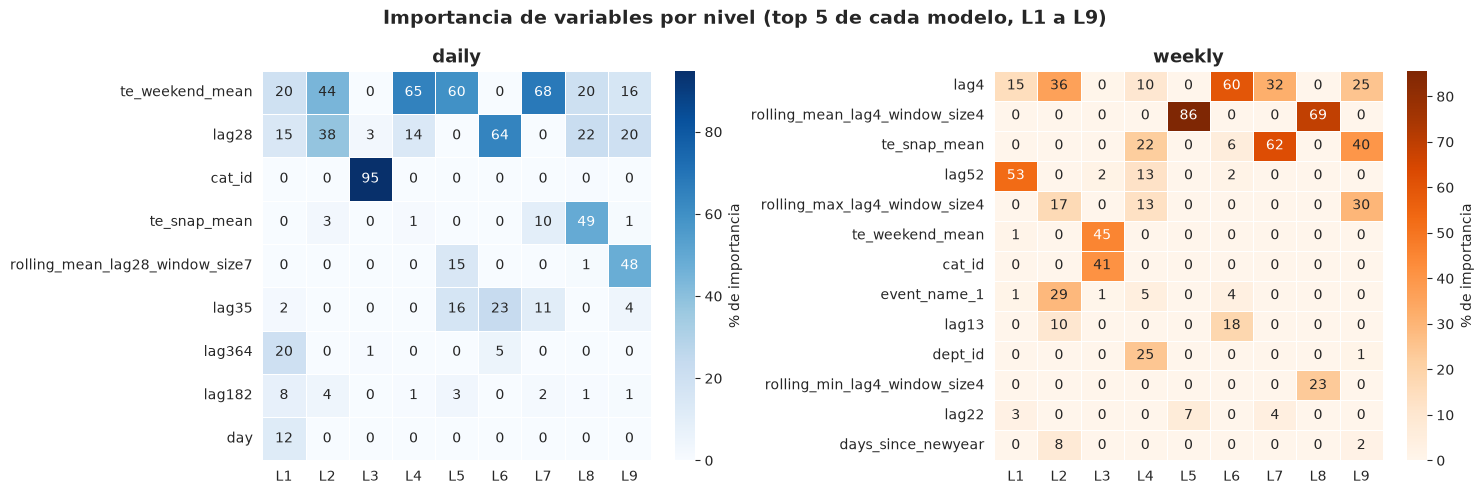

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, grain in zip(axes, ["daily", "weekly"]):
    top = 5
    data = build_importance_heatmap_data(grain, top_n=top).query("total_importance > 10").drop(columns="total_importance")
    sns.heatmap(
        data,
        annot=True,
        fmt=".0f",
        cmap="Blues" if grain == "daily" else "Oranges",
        cbar_kws={"label": "% de importancia"},
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(grain, fontsize=13, fontweight="bold", loc="center")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(
    f"Importancia de variables por nivel (top {top} de cada modelo, L1 a L9)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

In [183]:
data

,L1,L2,L3,L4,L5,L6,L7,L8,L9,total_importance
feature,,,,,,,,,,
lag4,14.9680,36.1999,0.4807,9.9195,0.0000,59.8496,31.8270,0.0000,25.3473,178.5920
rolling_mean_lag4_window_size4,0.0000,0.0000,0.0101,0.0000,85.6198,0.0000,0.0000,69.0668,0.0000,154.6966
te_snap_mean,0.0000,0.0000,0.0000,22.2198,0.0000,5.8379,62.3258,0.0000,40.1173,130.5008
lag52,53.0370,0.0000,1.8209,12.7016,0.0000,1.5307,0.0000,0.0000,0.0000,69.0901
rolling_max_lag4_window_size4,0.0000,16.5579,0.0000,13.2446,0.0000,0.0000,0.0000,0.0000,29.6771,59.4796
te_weekend_mean,0.8777,0.0000,45.4491,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,46.3268
cat_id,0.0000,0.0000,41.3077,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,41.3077
event_name_1,1.1491,29.0911,0.5288,4.6544,0.0000,3.7850,0.0000,0.0000,0.0000,39.2085
lag13,0.0000,10.2276,0.0877,0.0000,0.0000,18.3222,0.0000,0.0000,0.0000,28.6376
